# EDA — Análisis exploratorio (TFM)

Mismo contenido que `eda_analysis.py`, con gráficas **inline** en el notebook (sin guardar PNG en `data/`).

Ejecuta las celdas en orden. Requiere haber generado los CSV en `data/` (pipeline previo).

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings("ignore")

from config import DATA_DIR, SECTOR_ETFS, OOS_START, TRAIN_START

In [2]:
REGIME_COLORS = {0: "#d62728", 1: "#ff7f0e", 2: "#2ca02c"}
REGIME_LABELS = {0: "Bear", 1: "Ranging", 2: "Bull"}

## 1. Precios normalizados — ETFs + SPY

In [3]:
def plot_etf_prices(base_date: str = TRAIN_START, data_dir: str = DATA_DIR) -> None:
    prices = pd.read_csv(f"{data_dir}/etf_prices.csv", index_col=0, parse_dates=True)
    subset = prices.loc[prices.index >= base_date]
    base = subset.iloc[0]
    norm = subset / base * 100

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(norm.index, norm["SPY"], color="black", lw=2.5, label="SPY", zorder=10)
    ax.axvline(pd.Timestamp(OOS_START), color="gray", lw=1.2, ls="--", alpha=0.7,
               label=f"OOS start ({OOS_START[:4]})")
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i / len(SECTOR_ETFS)) for i in range(len(SECTOR_ETFS))]
    for etf, color in zip(SECTOR_ETFS, colors):
        ax.plot(norm.index, norm[etf], lw=1.3, alpha=0.85, label=etf, color=color)
    ax.axhline(100, color="gray", lw=0.8, ls=":", alpha=0.5)
    ax.set_title(
        f"Precios normalizados — ETFs sectoriales + SPY  (base 100 = {base_date})\n"
        f"Frecuencia semanal (W-FRI) · 2008–2024",
        fontsize=12, fontweight="bold",
    )
    ax.set_ylabel("Valor (base 100)")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}"))
    ax.legend(ncol=4, fontsize=8, loc="upper left", framealpha=0.85)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

## 2. SPY con fondo por régimen HMM

In [4]:
def plot_regime_overlay(data_dir: str = DATA_DIR) -> None:
    prices = pd.read_csv(f"{data_dir}/etf_prices.csv", index_col=0, parse_dates=True)
    regimes = pd.read_csv(f"{data_dir}/market_regimes.csv", index_col=0, parse_dates=True)
    spy = prices["SPY"].reindex(regimes.index).ffill()
    spy = spy.dropna()
    base = spy[spy.index >= TRAIN_START].iloc[0]
    spy_norm = spy / base * 100
    reg = regimes["market_regime"].reindex(spy_norm.index).ffill()

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={"height_ratios": [3, 1]})
    fig.suptitle(
        "SPY — Precio normalizado con regímenes HMM (Bear / Ranging / Bull)\n"
        "Rojo = Bear · Naranja = Ranging · Verde = Bull",
        fontsize=12, fontweight="bold",
    )
    ax = axes[0]
    dates = spy_norm.index
    regime_vals = reg.values
    for k, color in REGIME_COLORS.items():
        in_regime = False
        start_d = None
        for i, (d, r) in enumerate(zip(dates, regime_vals)):
            if r == k and not in_regime:
                in_regime = True
                start_d = d
            elif r != k and in_regime:
                ax.axvspan(start_d, d, color=color, alpha=0.15, lw=0)
                in_regime = False
        if in_regime:
            ax.axvspan(start_d, dates[-1], color=color, alpha=0.15, lw=0)
    ax.plot(spy_norm.index, spy_norm.values, color="black", lw=1.8, label="SPY")
    ax.axvline(pd.Timestamp(OOS_START), color="gray", lw=1.2, ls="--",
               alpha=0.7, label=f"OOS start ({OOS_START[:4]})")
    ax.axhline(100, color="gray", lw=0.6, ls=":", alpha=0.4)
    legend_patches = [Patch(color=REGIME_COLORS[k], alpha=0.5, label=REGIME_LABELS[k]) for k in range(3)]
    ax.legend(handles=legend_patches + [plt.Line2D([0], [0], color="black", lw=1.8, label="SPY")],
              fontsize=9, framealpha=0.85)
    ax.set_ylabel("Valor SPY (base 100)")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}"))
    ax.grid(True, alpha=0.2)

    ax2 = axes[1]
    ax2.fill_between(dates, reg.values, step="mid", color="steelblue", alpha=0.6)
    ax2.set_yticks([0, 1, 2])
    ax2.set_yticklabels(["Bear", "Ranging", "Bull"], fontsize=8)
    ax2.set_ylabel("Régimen")
    ax2.axvline(pd.Timestamp(OOS_START), color="gray", lw=1.2, ls="--", alpha=0.7)
    ax2.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

## 3. Panel de variables macroeconómicas

In [5]:
def plot_macro_series(data_dir: str = DATA_DIR) -> None:
    macro = pd.read_csv(f"{data_dir}/fred_macro.csv", index_col=0, parse_dates=True)
    macro = macro.loc[macro.index >= TRAIN_START]
    series_config = [
        ("VIX", "VIX (miedo de mercado)", "tab:red", False),
        ("T10", "Treasury 10Y (%)", "tab:blue", False),
        ("Term_Spread_10_3m", "Spread 10Y–3M (pb)", "tab:purple", False),
        ("HY_OAS", "HY OAS (crédito alto riesgo)", "tab:orange", False),
        ("ISM", "ISM / Chicago Fed NAI", "tab:green", False),
        ("CPI_YoY", "CPI YoY (%)", "tab:brown", True),
        ("FedFunds", "Fed Funds Rate (%)", "tab:cyan", False),
        ("Gold_ret_4w", "Oro — retorno 4 semanas", "goldenrod", True),
    ]
    available = [(s, t, c, p) for s, t, c, p in series_config if s in macro.columns]
    n = len(available)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.8), sharex=True)
    axes = axes.flatten()
    fig.suptitle(
        "Variables macroeconómicas — Evolución temporal\n"
        f"Periodo: {TRAIN_START[:4]}–2024  (semanal W-FRI)",
        fontsize=12, fontweight="bold",
    )
    for ax, (series, title, color, pct_fmt) in zip(axes, available):
        s = macro[series].dropna()
        ax.plot(s.index, s.values, color=color, lw=1.2)
        ax.axvline(pd.Timestamp(OOS_START), color="gray", lw=0.9, ls="--", alpha=0.6)
        ax.axhline(0, color="gray", lw=0.6, ls=":", alpha=0.4)
        ax.set_title(title, fontsize=9, fontweight="bold")
        if pct_fmt:
            ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.1%}"))
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## 4. Distribución del target por régimen

In [6]:
def plot_returns_distribution(data_dir: str = DATA_DIR) -> None:
    panel = pd.read_csv(f"{data_dir}/features_panel_with_regime.csv", parse_dates=["date"])
    panel_is = panel[(panel["date"] >= TRAIN_START) & (panel["date"] < OOS_START)].dropna(
        subset=["target", "market_regime"]
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "Distribución del target (exceso ETF vs SPY, semana t+1) — IS 2008–2023\n"
        "Por régimen HMM: Bear / Ranging / Bull",
        fontsize=12, fontweight="bold",
    )
    ax = axes[0]
    bins = np.linspace(-0.12, 0.12, 80)
    stats_rows = []
    for k, label in REGIME_LABELS.items():
        subset = panel_is[panel_is["market_regime"] == k]["target"]
        if subset.empty:
            continue
        ax.hist(subset, bins=bins, alpha=0.45, color=REGIME_COLORS[k],
                label=f"{label} (n={len(subset):,})", density=True)
        stats_rows.append({
            "Régimen": label,
            "Media": f"{subset.mean():+.4f}",
            "Std": f"{subset.std():.4f}",
            "% Positivo": f"{(subset > 0).mean():.1%}",
            "n ETF-sem": f"{len(subset):,}",
        })
    ax.axvline(0, color="black", lw=1.0, ls="--", alpha=0.5)
    ax.set_xlabel("Target (exceso vs SPY, t+1)")
    ax.set_ylabel("Densidad")
    ax.set_title("Histograma por régimen")
    ax.legend(fontsize=9, framealpha=0.85)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.grid(True, alpha=0.2)

    ax2 = axes[1]
    ax2.axis("off")
    if stats_rows:
        df_stats = pd.DataFrame(stats_rows)
        tbl = ax2.table(cellText=df_stats.values, colLabels=df_stats.columns, loc="center", cellLoc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1.2, 2.0)
        for row_idx, k in enumerate([r for r in range(3) if not panel_is[panel_is["market_regime"] == r].empty]):
            for col_idx in range(len(df_stats.columns)):
                cell = tbl[row_idx + 1, col_idx]
                cell.set_facecolor(mcolors.to_rgba(REGIME_COLORS[k], alpha=0.15))
    ax2.set_title("Estadísticos por régimen", fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 5. Heatmap de correlación macro

In [7]:
def plot_correlation_heatmap(data_dir: str = DATA_DIR) -> None:
    macro = pd.read_csv(f"{data_dir}/fred_macro.csv", index_col=0, parse_dates=True)
    macro = macro.loc[macro.index >= TRAIN_START]
    level_cols = [
        "VIX", "T10", "T3M", "YieldSpread", "Term_Spread_10_3m",
        "FedFunds", "RepoRate", "HY_OAS", "IG_OAS", "JGB10Y",
        "US_JP_Spread", "ISM", "CPI_YoY", "IndProd_YoY", "Unemployment",
        "Gold_ret_4w", "Oil_ret_4w",
    ]
    cols_avail = [c for c in level_cols if c in macro.columns]
    sub = macro[cols_avail].dropna(how="all")
    corr = sub.corr(method="pearson", min_periods=50)
    n = len(cols_avail)
    fig, ax = plt.subplots(figsize=(max(10, n * 0.7), max(8, n * 0.65)))
    fig.suptitle(
        "Correlación de Pearson — Variables macroeconómicas (nivel)\n"
        f"Periodo: {TRAIN_START[:4]}–2024  (semanal W-FRI, pares completos)",
        fontsize=11, fontweight="bold",
    )
    cmap = plt.get_cmap("RdYlGn")
    im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
    for i in range(n):
        for j in range(n):
            val = corr.values[i, j]
            if not np.isnan(val):
                txt_color = "white" if abs(val) > 0.7 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6.5, color=txt_color)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(cols_avail, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(cols_avail, fontsize=8)
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Correlación de Pearson", fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

## Ejecutar todas las gráficas

[etf] Precios normalizados ETFs + SPY


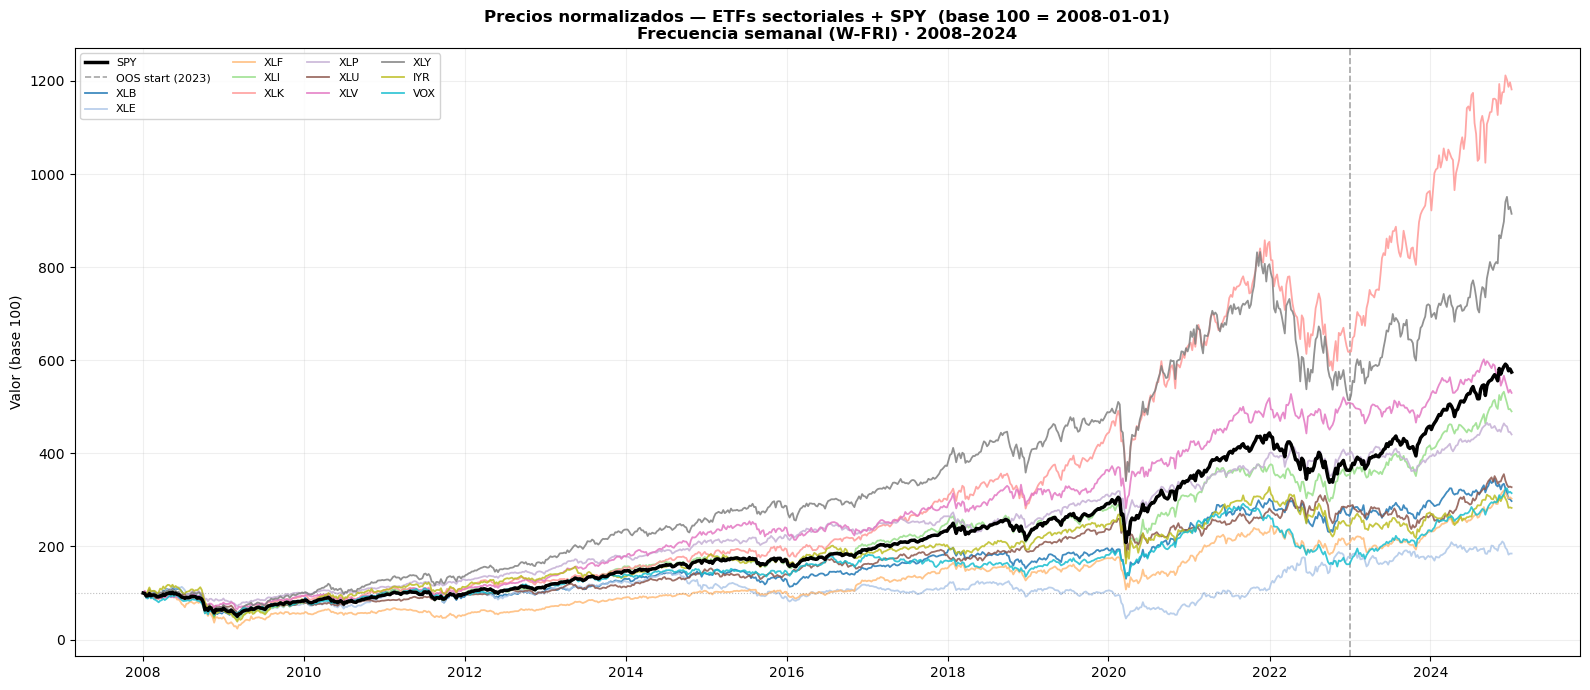

[regime] SPY con fondo por régimen HMM


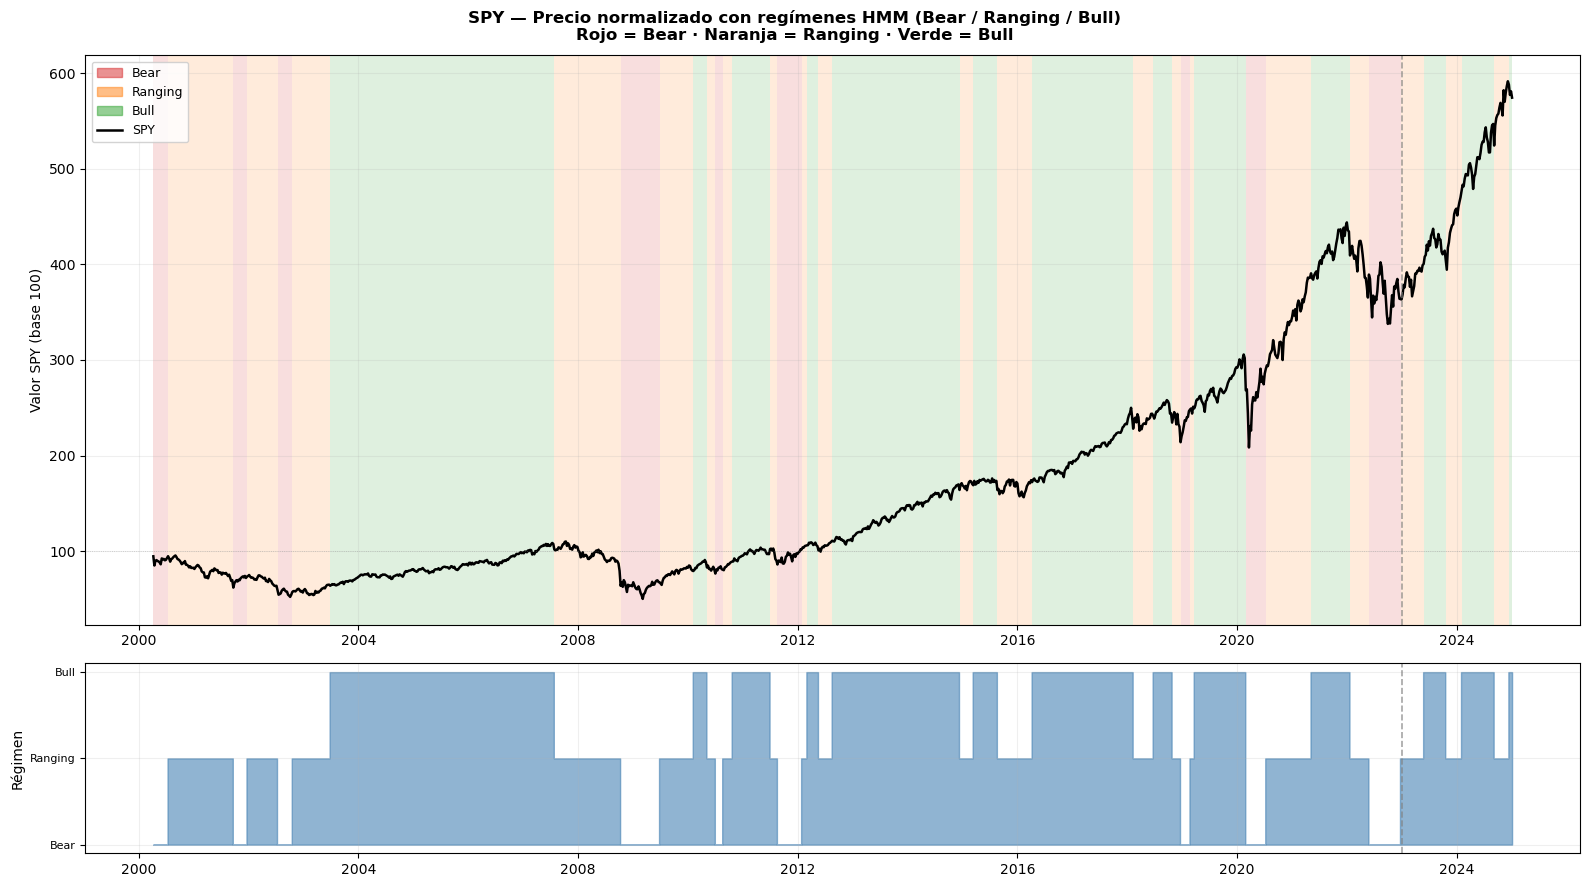

[macro] Panel variables macroeconómicas


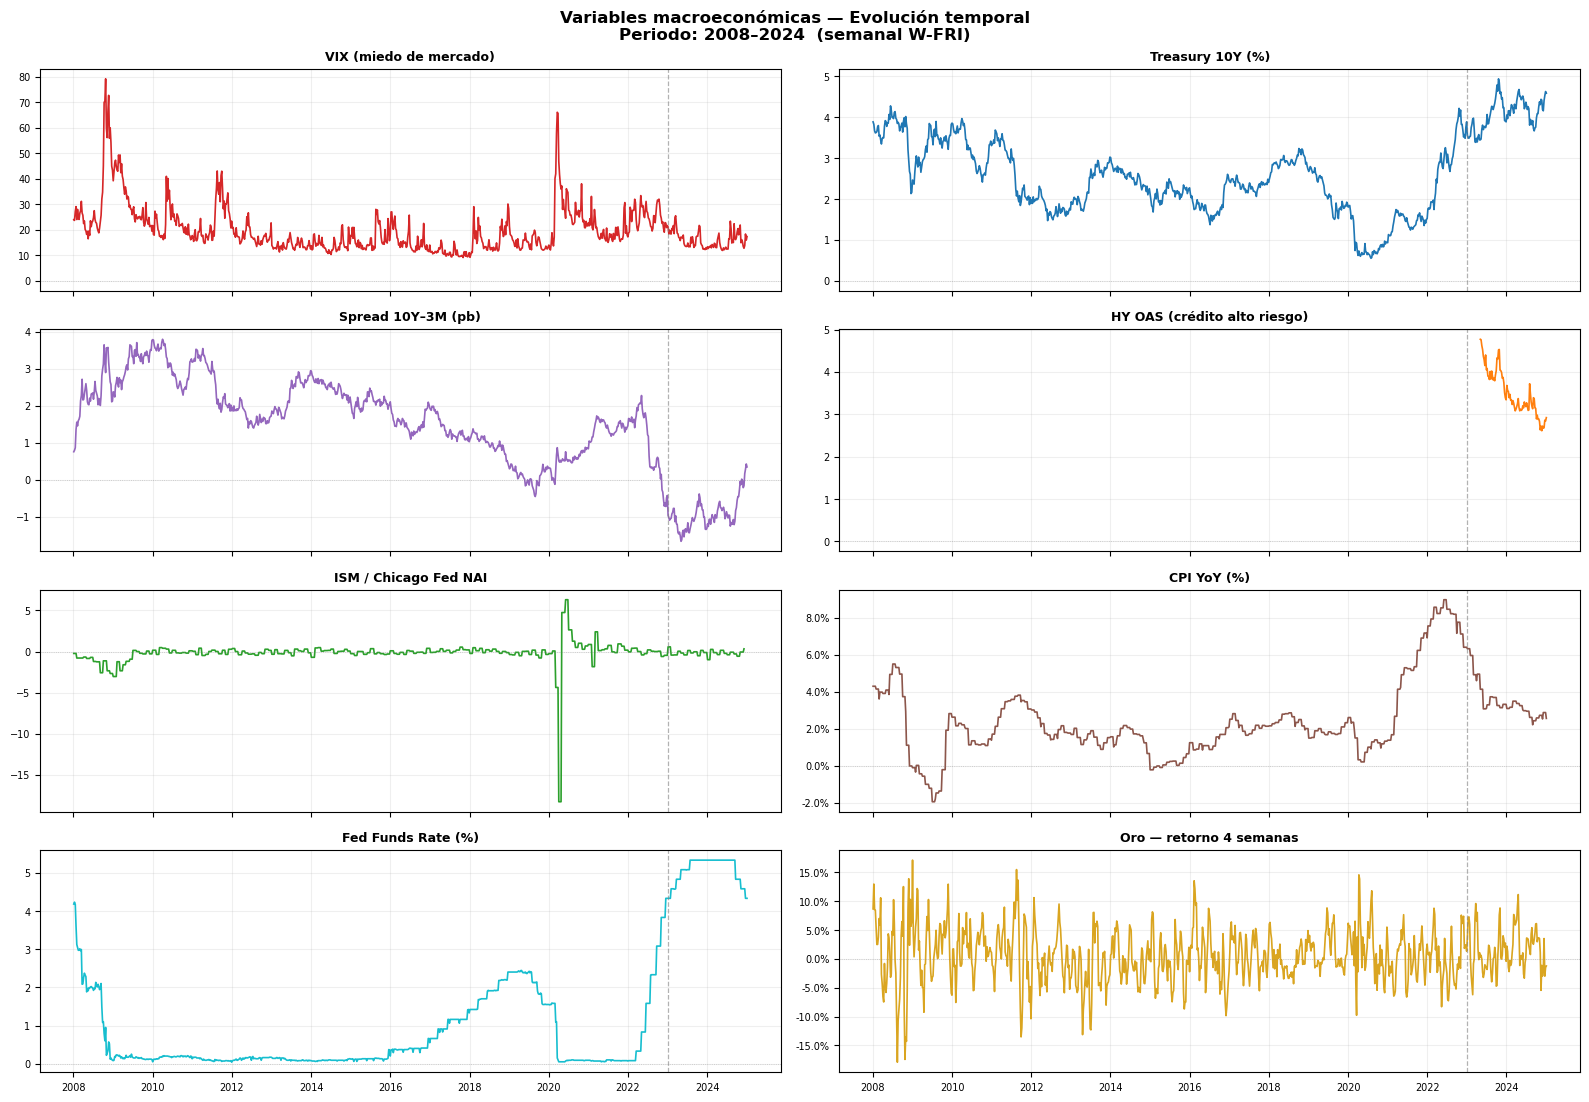

[dist] Distribución del target por régimen


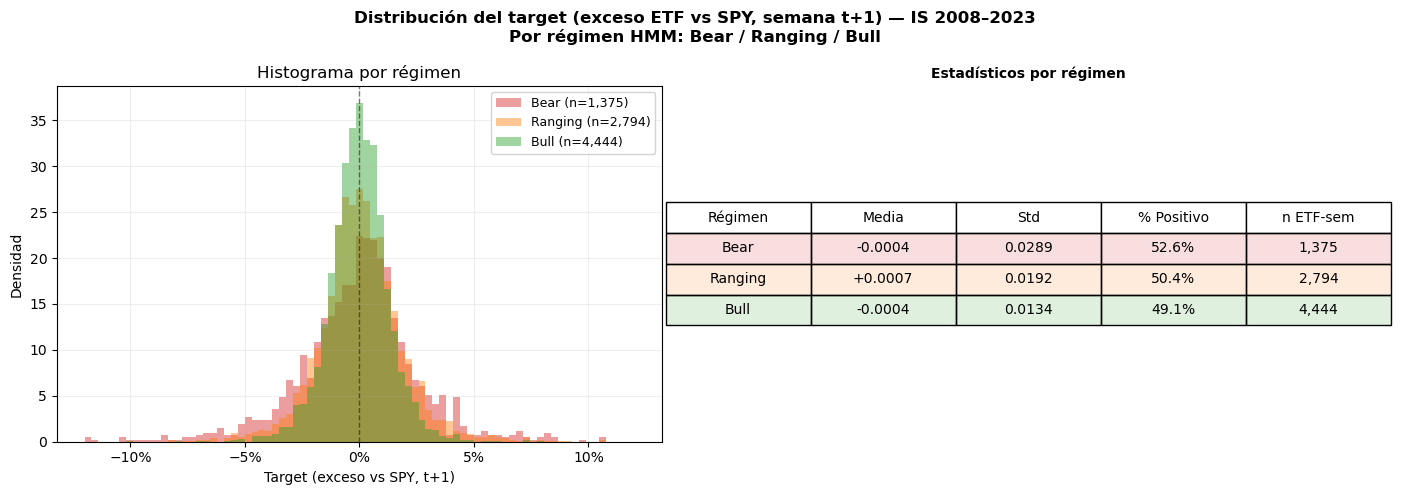

[corr] Heatmap correlación macro


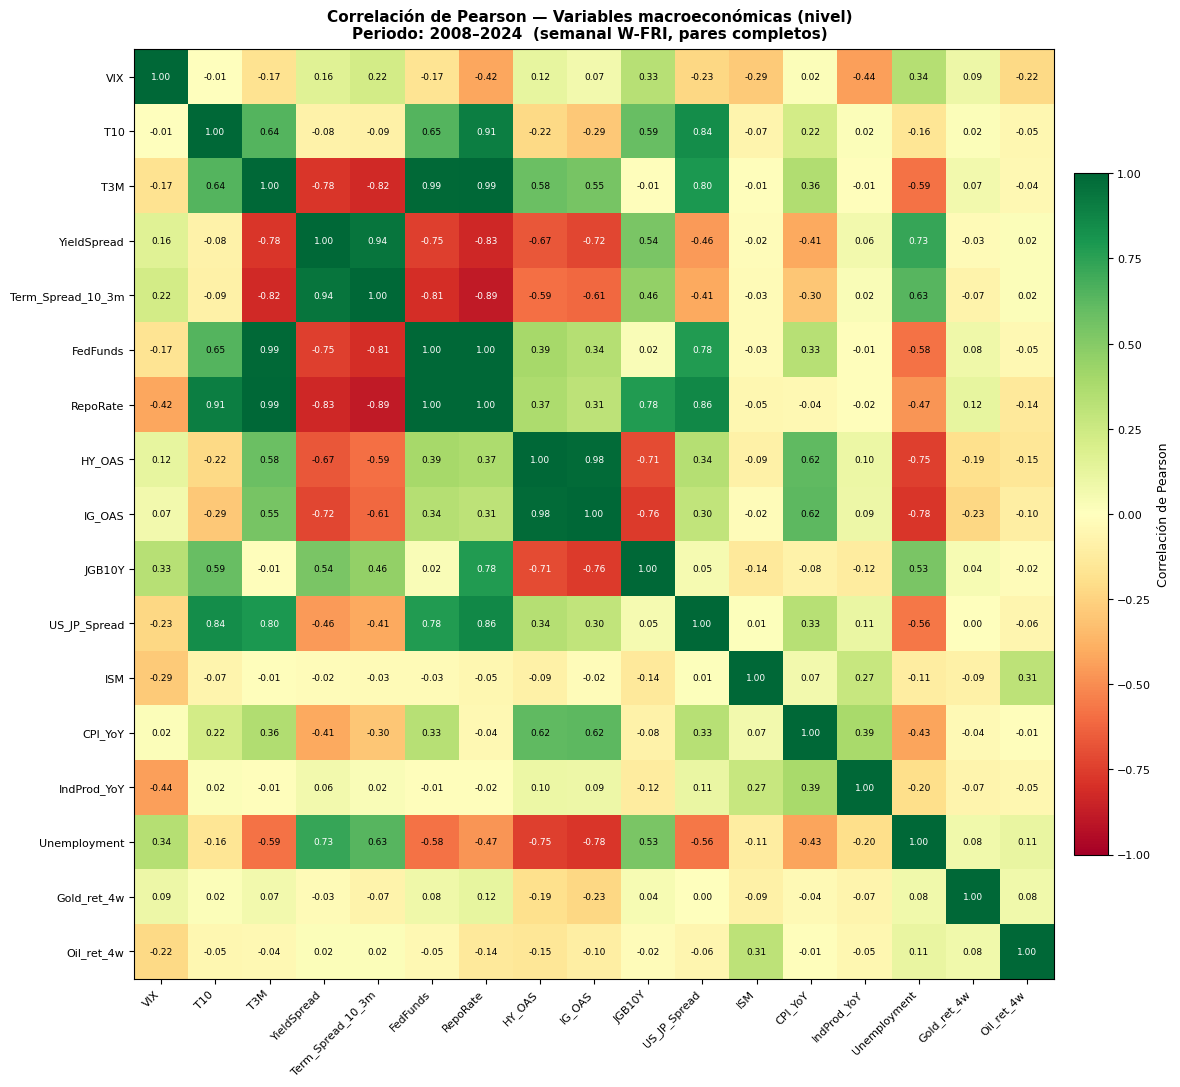

In [8]:
_FUNCS = [
    ("etf", plot_etf_prices, "Precios normalizados ETFs + SPY"),
    ("regime", plot_regime_overlay, "SPY con fondo por régimen HMM"),
    ("macro", plot_macro_series, "Panel variables macroeconómicas"),
    ("dist", plot_returns_distribution, "Distribución del target por régimen"),
    ("corr", plot_correlation_heatmap, "Heatmap correlación macro"),
]

for key, fn, desc in _FUNCS:
    print(f"[{key}] {desc}")
    try:
        fn()
    except FileNotFoundError as e:
        print(f"  [!] Archivo no encontrado: {e}")
    except Exception as e:
        print(f"  [ERROR] {key}: {e}")